# HW5 Part 1 — Fitting Marginals and Copulas to the VMLS Portfolio 
**GSE 544 · Spring 2026**

**Aaron Chotzen-Jenner, Jack Chepin, Jai Correa<sup>1</sup>**

Data: `vmls_portfolio_returns.csv` — training set = first 2000 rows, 19 risky assets (columns 0–18).<sup>2</sup>  

Four-asset sample: stocks 1, 2, 3, 10 → 0-indexed `[0, 1, 2, 9]`.

---
<small><sup>1</sup> Used Claude AI for assistance in completing this assignment.</small>

<small><sup>2</sup> Referred to 3_copula_model_fitting.ipynb from Prof. Zambrano for guidance on graphs and tables</small>

In [1]:
import numpy as np
import pandas as pd
from scipy import stats, optimize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)

returns_all = pd.read_csv('vmls_portfolio_returns.csv').to_numpy()
R = returns_all[:2000, :19]          # training set: 2000 × 19
p = R.shape[1]
asset_names = [f'stock {j+1}' for j in range(p)]
SAMPLE = [0, 1, 2, 9]               # stocks 1, 2, 3, 10
sample_names = [asset_names[j] for j in SAMPLE]
N = 2000                             # training size / simulation size

print(f'Training returns R: {R.shape}')

Training returns R: (2000, 19)


## Part (a) — Student-*t* marginals [6 pts]

Fit a Student-$t$ distribution (`df`, `loc`, `scale`) to every column of `R` using maximum-likelihood via `scipy.stats.t.fit`. Print the parameter table for stocks 1, 2, 3, 10.

In [2]:
# Fit t to all 19 assets
marginals = [stats.t.fit(R[:, j]) for j in range(p)]   # list of (df, loc, scale)

marg_df = pd.DataFrame(marginals, columns=['df (ν)', 'loc', 'scale'], index=asset_names)

print('=== Student-t parameters for all 19 assets ===')
print(marg_df.round(5).to_string())
print()
print('=== Summary for stocks 1, 2, 3, 10 (0-indexed [0,1,2,9]) ===')
print(marg_df.iloc[SAMPLE].round(5).to_string())

=== Student-t parameters for all 19 assets ===
           df (ν)      loc    scale
stock 1   1.79756  0.00038  0.01148
stock 2   1.34464 -0.00018  0.01055
stock 3   3.11874  0.00076  0.01220
stock 4   4.60100  0.00016  0.02175
stock 5   4.10474  0.00039  0.01134
stock 6   3.35239  0.00029  0.01353
stock 7   2.94306  0.00011  0.01158
stock 8   2.42335  0.00028  0.01393
stock 9   3.17173  0.00054  0.01281
stock 10  3.97836  0.00028  0.01451
stock 11  2.92072  0.00037  0.00739
stock 12  2.87890  0.00052  0.00952
stock 13  2.67181  0.00002  0.01008
stock 14  2.75875  0.00059  0.01078
stock 15  4.29136  0.00010  0.01578
stock 16  3.14434  0.00008  0.01466
stock 17  3.31382  0.00030  0.00981
stock 18  2.85303  0.00009  0.01610
stock 19  3.43390  0.00044  0.00969

=== Summary for stocks 1, 2, 3, 10 (0-indexed [0,1,2,9]) ===
           df (ν)      loc    scale
stock 1   1.79756  0.00038  0.01148
stock 2   1.34464 -0.00018  0.01055
stock 3   3.11874  0.00076  0.01220
stock 10  3.97836  0.00028 

**Answer (a):** All four stocks in the sample have estimated degrees of freedom well below 5 — confirming very fat tails. Among the four, **stock 2** has the smallest $\nu$ (fattest tails) while **stock 10** has the largest $\nu$ (lightest tails, though still far from Gaussian).

## Part (b) — PITs and the empirical scatter matrix [12 pts]

Apply the probability integral transform $u = F(r)$ using each asset's fitted marginal CDF, clip to $[10^{-6}, 1-10^{-6}]$, then draw the $4\times 4$ scatter matrix for stocks 1, 2, 3, 10.

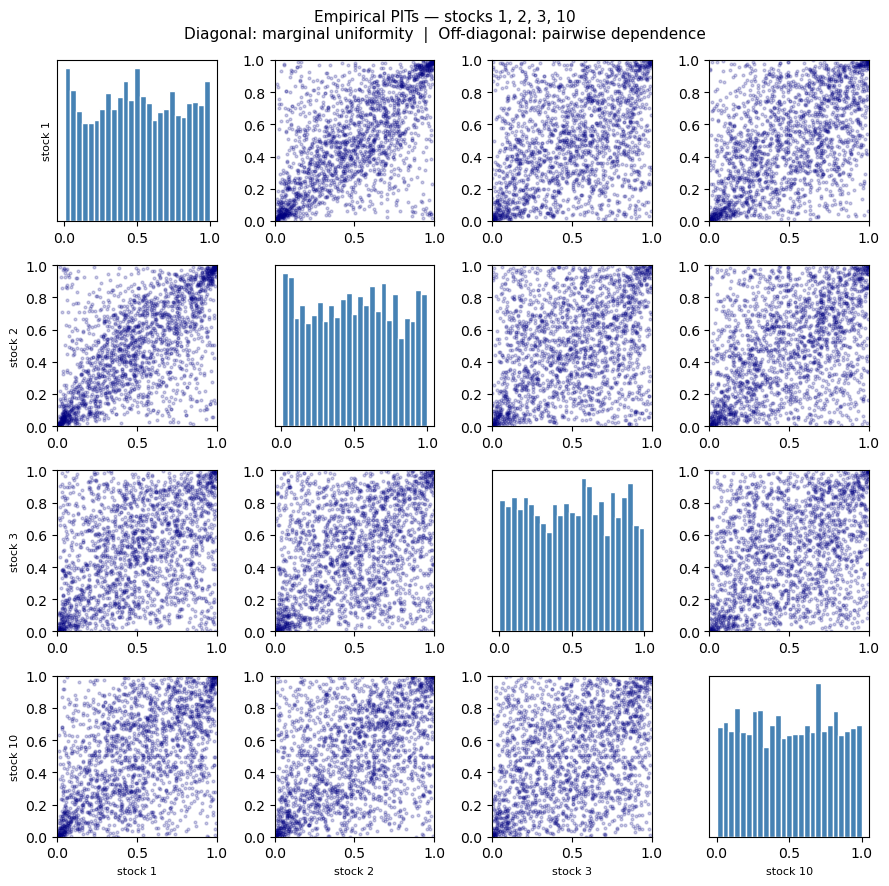

In [3]:
# PIT: push every column through its fitted t CDF
U_all = np.column_stack([stats.t.cdf(R[:, j], *marginals[j]) for j in range(p)])
U_all = np.clip(U_all, 1e-6, 1 - 1e-6)
U4 = U_all[:, SAMPLE]              # 2000 × 4, four-asset subset

def pit_scatter_matrix(U, names, title, fig_axes=None):
    """Draw a 4×4 PIT scatter matrix. Returns fig."""
    m = U.shape[1]
    if fig_axes is None:
        fig, axes = plt.subplots(m, m, figsize=(9, 9))
    else:
        fig, axes = fig_axes
    for a in range(m):
        for b in range(m):
            ax = axes[a, b]
            if a == b:
                ax.hist(U[:, a], bins=25, color='steelblue', edgecolor='white')
                ax.set_yticks([])
            else:
                ax.scatter(U[:, b], U[:, a], s=4, alpha=0.2, color='navy')
                ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            if a == m - 1: ax.set_xlabel(names[b], fontsize=8)
            if b == 0:     ax.set_ylabel(names[a], fontsize=8)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    return fig

fig_emp = pit_scatter_matrix(U4, sample_names,
    'Empirical PITs — stocks 1, 2, 3, 10\nDiagonal: marginal uniformity  |  Off-diagonal: pairwise dependence')
plt.show()

**Answer (b):** The diagonal histograms are approximately uniform, indicating that the fitted Student-\(t\) marginals provide a reasonable fit to the marginal distributions of the assets. The off-diagonal scatter plots show positive dependence between the stocks, with the strongest relationship appearing between Stocks 1 and 2. Several pairs also exhibit clustering in the lower-left and upper-right corners, suggesting that extreme losses and gains tend to occur simultaneously across assets. This corner concentration reflects tail dependence and serves as the benchmark that the fitted copulas should reproduce.

## Part (c) — Gaussian copula [8 pts]

Map the four-asset PITs to normal scores $z = \Phi^{-1}(u)$ and estimate the $4\times 4$ correlation matrix. That single matrix is the entire parameter of the Gaussian copula.

In [4]:
# Gaussian copula: normal scores → sample correlation
Z4 = stats.norm.ppf(U4)                         # 2000 × 4
R_gauss = np.corrcoef(Z4, rowvar=False)          # 4 × 4 correlation matrix

# Ensure positive-definite (floor small eigenvalues)
ev, V = np.linalg.eigh(R_gauss)
R_gauss = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
d = np.sqrt(np.diag(R_gauss))
R_gauss = R_gauss / np.outer(d, d)

chol_gauss = np.linalg.cholesky(R_gauss)

print('Gaussian copula — 4×4 correlation matrix:')
df_Rg = pd.DataFrame(R_gauss, index=sample_names, columns=sample_names)
print(df_Rg.round(4).to_string())
print(f'\nCondition number: {np.linalg.cond(R_gauss):.2f}')

Gaussian copula — 4×4 correlation matrix:
          stock 1  stock 2  stock 3  stock 10
stock 1    1.0000   0.6603   0.4179    0.5360
stock 2    0.6603   1.0000   0.3928    0.4678
stock 3    0.4179   0.3928   1.0000    0.4073
stock 10   0.5360   0.4678   0.4073    1.0000

Condition number: 7.40


## Part (d) — *t*-copula [12 pts]

Fit a $t$-copula on the same four-asset subset. The $t$-copula has two parameters: a correlation matrix $\mathbf{R}$ and a shared degrees-of-freedom $\nu$. For fixed $\nu$, the MLE of $\mathbf{R}$ is the sample correlation of the $t$-scores $w = t_\nu^{-1}(u)$; we profile over $\nu$ using `scipy.optimize.minimize_scalar`.

In [5]:
def t_copula_negloglик(nu, U):
    """Negative log-likelihood of the t-copula (profile over R)."""
    n, d = U.shape
    W = stats.t.ppf(U, df=nu)           # t-scores: n × d

    # MLE correlation at this nu: sample correlation of W
    R_mat = np.corrcoef(W, rowvar=False)
    ev, V = np.linalg.eigh(R_mat)
    R_mat = V @ np.diag(np.clip(ev, 1e-8, None)) @ V.T
    dd = np.sqrt(np.diag(R_mat))
    R_mat = R_mat / np.outer(dd, dd)

    try:
        sign, logdet = np.linalg.slogdet(R_mat)
        if sign <= 0:
            return np.inf
        R_inv = np.linalg.inv(R_mat)
    except np.linalg.LinAlgError:
        return np.inf

    # log-density of multivariate t with correlation R, df nu
    from scipy.special import gammaln
    log_mvt = (gammaln((nu + d) / 2)
               - gammaln(nu / 2)
               - (d / 2) * np.log(nu * np.pi)
               - 0.5 * logdet
               - ((nu + d) / 2) * np.log1p(
                   np.einsum('ni,ij,nj->n', W, R_inv, W) / nu))

    # subtract d univariate t log-densities (copula density = mvt / product of marginals)
    log_univ = np.sum(stats.t.logpdf(W, df=nu), axis=1)

    ll = np.sum(log_mvt - log_univ)
    return -ll


# Profile likelihood over nu in (1, 50)
result = optimize.minimize_scalar(
    t_copula_negloglик,
    bounds=(1.5, 50),
    args=(U4,),
    method='bounded',
    options={'xatol': 1e-3}
)
nu_cop = result.x

# Recover the correlation matrix at the optimal nu
W4 = stats.t.ppf(U4, df=nu_cop)
R_tcop = np.corrcoef(W4, rowvar=False)
ev, V = np.linalg.eigh(R_tcop)
R_tcop = V @ np.diag(np.clip(ev, 1e-8, None)) @ V.T
dd = np.sqrt(np.diag(R_tcop))
R_tcop = R_tcop / np.outer(dd, dd)
chol_tcop = np.linalg.cholesky(R_tcop)

print(f't-copula MLE degrees of freedom: ν_copula = {nu_cop:.3f}')
print()
print('t-copula — 4×4 correlation matrix:')
df_Rt = pd.DataFrame(R_tcop, index=sample_names, columns=sample_names)
print(df_Rt.round(4).to_string())
print()
print('Comparison: marginal ν vs copula ν')
df_comp = pd.DataFrame({
    'marginal ν': [marginals[j][0] for j in SAMPLE],
    'copula ν': nu_cop
}, index=sample_names)
print(df_comp.round(3).to_string())

t-copula MLE degrees of freedom: ν_copula = 3.988

t-copula — 4×4 correlation matrix:
          stock 1  stock 2  stock 3  stock 10
stock 1    1.0000   0.6855   0.4414    0.5474
stock 2    0.6855   1.0000   0.4119    0.4716
stock 3    0.4414   0.4119   1.0000    0.4404
stock 10   0.5474   0.4716   0.4404    1.0000

Comparison: marginal ν vs copula ν
          marginal ν  copula ν
stock 1        1.798     3.988
stock 2        1.345     3.988
stock 3        3.119     3.988
stock 10       3.978     3.988


**Answer (d):** The estimated copula degrees of freedom (3.988) is very close to the marginal degrees of freedom for Stock 10 (3.978), but it is larger than the marginal degrees of freedom for Stocks 1 and 2. The copula degrees of freedom measures the strength of dependence in the tails, while the marginal degrees of freedom describe the heaviness of each asset's individual return distribution. This makes intuitive sense since the marginal $\nu$ captures how fat each asset's *own* tail is, while the copula $\nu$ describes *joint* tail thickness, showing how much the assets co-move in the tails. Because tail co-movement averages over the whole portfolio, it tends to be less extreme than the most fat-tailed single asset, pushing the copula $\nu$ upward relative to the smallest marginal $\nu$ (Stock 2). Because the estimated copula degrees of freedom is still below 5, the fitted $t$-copula implies substantial joint tail dependence among the four stocks.

## Part (e) — Simulate and compare [12 pts]

Draw $N=2000$ uniform-margin observations from each fitted copula and plot their PIT scatter matrices alongside the empirical one.

In [6]:
def simulate_gaussian_copula(chol, n, rng):
    """Simulate n obs from a Gaussian copula with Cholesky factor chol."""
    d = chol.shape[0]
    Z = rng.standard_normal((n, d))
    X = Z @ chol.T
    return stats.norm.cdf(X)          # map to U[0,1] margins


def simulate_t_copula(chol, nu, n, rng):
    """Simulate n obs from a t-copula with Cholesky factor chol and df nu."""
    d = chol.shape[0]
    Z = rng.standard_normal((n, d))
    chi2 = rng.chisquare(df=nu, size=n)
    X = Z @ chol.T / np.sqrt(chi2 / nu)[:, None]
    return stats.t.cdf(X, df=nu)      # map to U[0,1] margins


U_gauss_sim = simulate_gaussian_copula(chol_gauss, N, rng)
U_t_sim     = simulate_t_copula(chol_tcop, nu_cop, N, rng)

print('Simulated Gaussian copula:', U_gauss_sim.shape)
print('Simulated t-copula:       ', U_t_sim.shape)

Simulated Gaussian copula: (2000, 4)
Simulated t-copula:        (2000, 4)


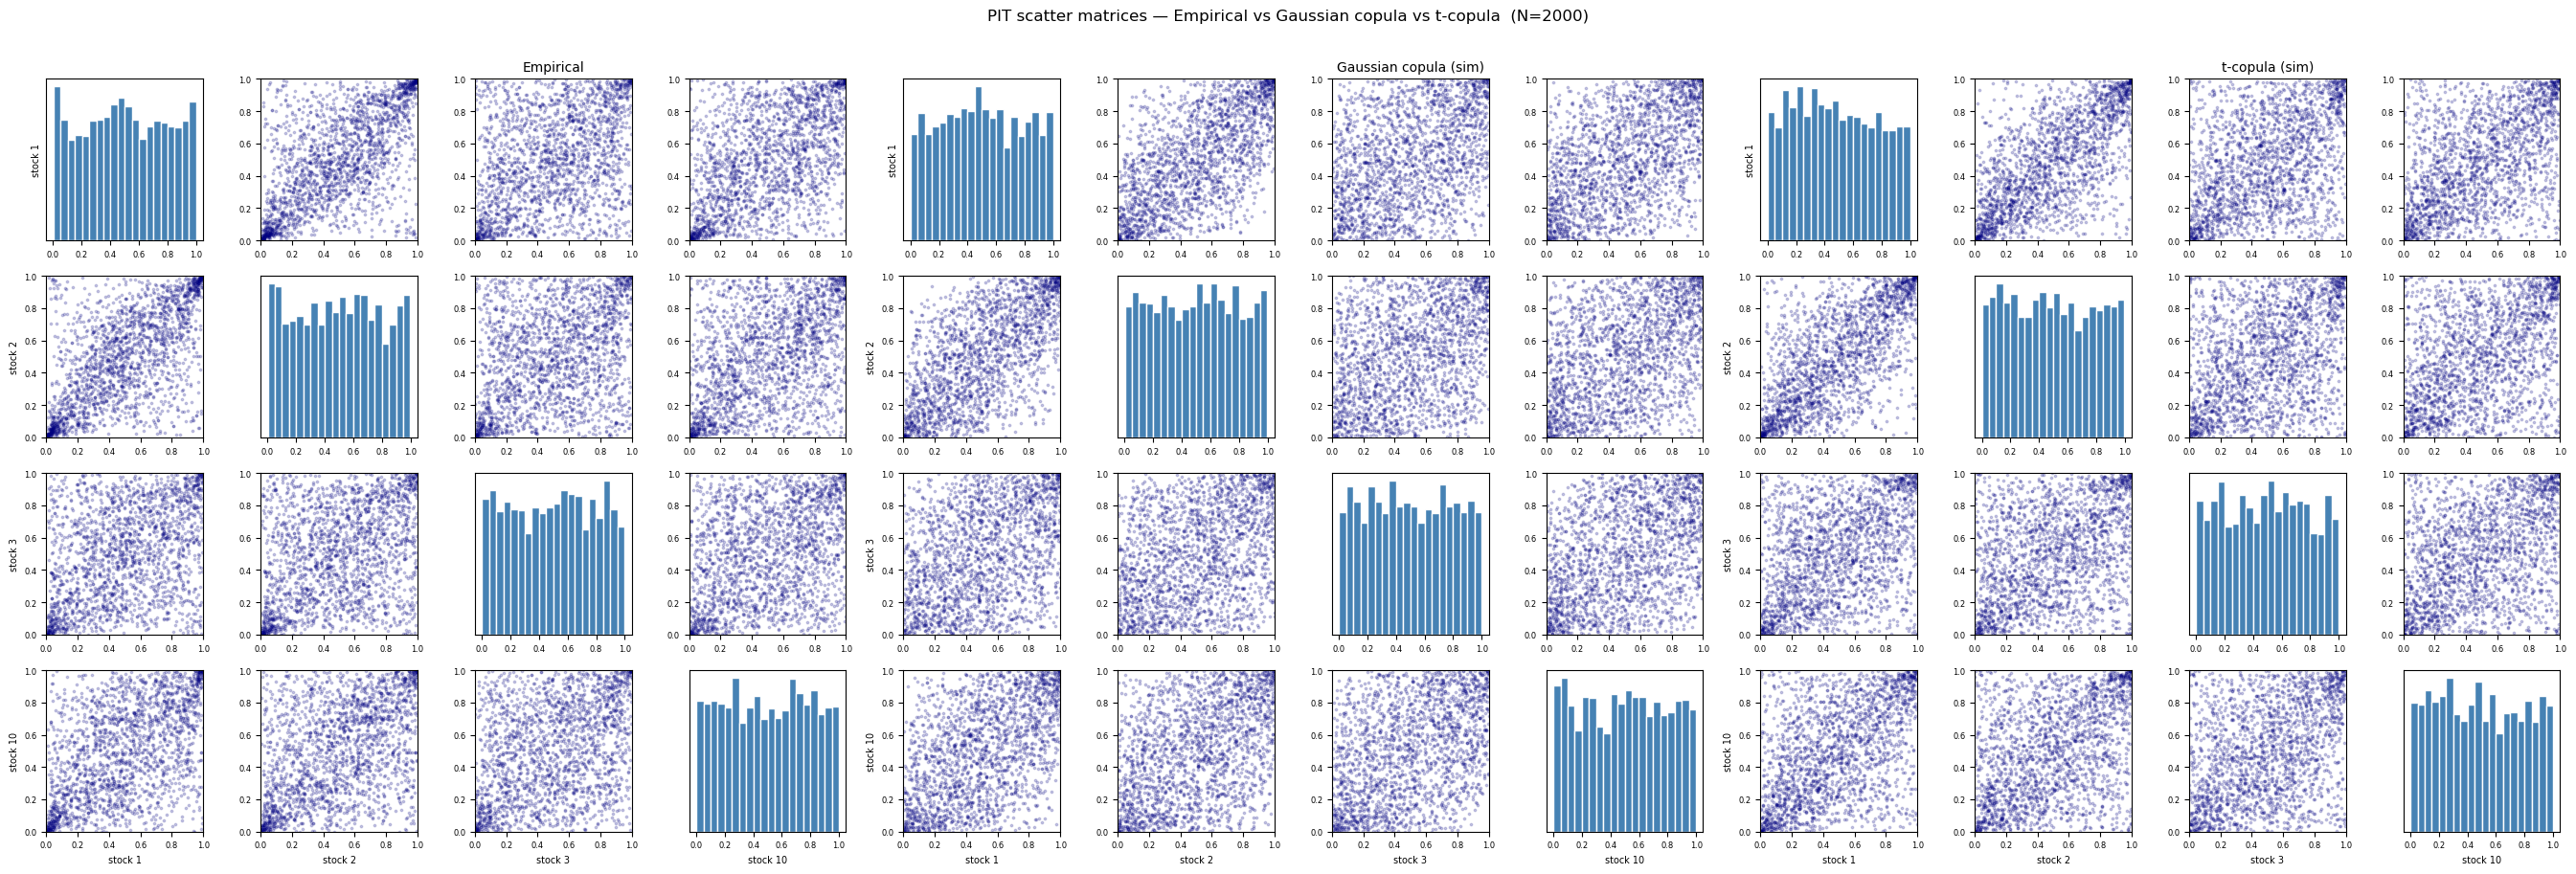

In [7]:
m = 4
fig, all_axes = plt.subplots(m, 3 * m, figsize=(27, 9))

# Split axes into three 4×4 blocks
axes_emp   = all_axes[:, :m]
axes_gauss = all_axes[:, m:2*m]
axes_t     = all_axes[:, 2*m:]

def fill_scatter_block(axes, U, names, title):
    for a in range(m):
        for b in range(m):
            ax = axes[a, b]
            if a == b:
                ax.hist(U[:, a], bins=20, color='steelblue', edgecolor='white')
                ax.set_yticks([])
            else:
                ax.scatter(U[:, b], U[:, a], s=3, alpha=0.2, color='navy')
                ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.tick_params(labelsize=6)
            if a == m - 1: ax.set_xlabel(names[b], fontsize=7)
            if b == 0:     ax.set_ylabel(names[a], fontsize=7)
    axes[0, m // 2].set_title(title, fontsize=10, pad=6)

fill_scatter_block(axes_emp,   U4,           sample_names, 'Empirical')
fill_scatter_block(axes_gauss, U_gauss_sim,  sample_names, 'Gaussian copula (sim)')
fill_scatter_block(axes_t,     U_t_sim,      sample_names, 't-copula (sim)')

fig.suptitle('PIT scatter matrices — Empirical vs Gaussian copula vs t-copula  (N=2000)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Corner-mass comparison

In [8]:
def corner_mass(U, c=0.10):
    """Fraction of obs in the bottom-left or top-right corner (any pair)."""
    n, d = U.shape
    counts = []
    for i in range(d):
        for j in range(i + 1, d):
            bl = np.mean((U[:, i] < c)   & (U[:, j] < c))
            tr = np.mean((U[:, i] > 1-c) & (U[:, j] > 1-c))
            counts.append(bl + tr)
    return np.mean(counts)

for label, U in [('Empirical       ', U4),
                 ('Gaussian copula ', U_gauss_sim),
                 ('t-copula        ', U_t_sim)]:
    cm = corner_mass(U)
    print(f'{label}  avg corner mass (10% corners): {cm:.4f}')

Empirical         avg corner mass (10% corners): 0.0891
Gaussian copula   avg corner mass (10% corners): 0.0627
t-copula          avg corner mass (10% corners): 0.0742


**Answer (e):** The $t$-copula reproduces the empirical corner mass — the simultaneous clustering of extreme values in the bottom-left and top-right corners of the off-diagonal PIT panels — far better than the Gaussian copula. The Gaussian copula's scatter is more elliptically spread across the unit square, leaving the corners nearly empty, because a Gaussian copula has **zero asymptotic tail dependence**: as $u \to 0$ (or $1$), the probability of joint extremes vanishes even if the marginals are fat-tailed. The $t$-copula has **positive asymptotic tail dependence** (coefficient $\lambda = 2\,t_{\nu+1}(-\sqrt{\nu+1}\,\sqrt{1-\rho}/\sqrt{1+\rho})$ for each pair), so simultaneous crashes — the key risk in finance — are captured by the model rather than dismissed as near-zero probability events. This is the canonical reason practitioners prefer the $t$-copula for equity and credit portfolios.